In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import csv
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, GRU, Dense, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_auc_score, confusion_matrix

from gensim.models import Word2Vec

from imblearn.over_sampling import SMOTE
import ml_utils
import config_variables as cv

2025-01-02 19:20:23.484976: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-02 19:20:23.496030: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-02 19:20:23.499380: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import random

# Set random seeds for reproducibility
def set_seeds(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seeds()

In [3]:
FILE_ROOT = cv.FILE_ROOT
Num_Trials = cv.Num_Trials

csv_file_path = cv.csv_file_path
code_file_location = cv.code_file_location
Dataset_Number = cv.Dataset_Number
Dataset_Number_reps = cv.Dataset_Number_reps

#issue_number,file,line,rule,Number_of_items,isFalsePositive,description,Program_Slicing_Approach
ISSUE_NUMBER = cv.ISSUE_NUMBER
RULE = cv.RULE
IS_FALSE_POSITIVE = cv.IS_FALSE_POSITIVE
DESCRIPTION = cv.DESCRIPTION

model_path = f"{FILE_ROOT}/code_representation/representation_models/word2vec_model_{Dataset_Number_reps}.bin"
max_words = 18937 + 1  # Adjust based on your vocabulary size
GPU_Device = '/GPU:0'

In [4]:
def load_custom_word2vec(model_path):
    """
    Load the custom trained Word2Vec model
    """
    try:
        model = Word2Vec.load(model_path)
        print(f"Loaded Word2Vec model with {len(model.wv.key_to_index)} words")
        return model.wv
    except Exception as e:
        print(f"Error loading Word2Vec model: {str(e)}")
        raise
word_vectors = load_custom_word2vec(model_path)

Loaded Word2Vec model with 18937 words


In [5]:
def prepare_data_to_train(csv_file_path):

    feature_list = []
    label_list = []
    with open(csv_file_path, 'r') as file:
        reader = csv.reader(file)
        next(reader)  # Skip column names
        max_length = 0
        for row in reader:
            issue_number = row[ISSUE_NUMBER]
            description = row[DESCRIPTION]
            file_name = f"{code_file_location}/{issue_number}.txt"
            response = ml_utils.get_content_for_file(file_name, description)
            vector_length = len(response)
            if vector_length == 0:
                continue
            feature_list.append(response)
            vector_length = len(response)
            if vector_length > max_length:
                max_length = vector_length
            is_false_positive = row[IS_FALSE_POSITIVE]
            if is_false_positive == "FALSE":
                label_list.append(0)
            elif is_false_positive == "TRUE":
                label_list.append(1)
    # Convert labels to categorical
    #labels = to_categorical(label_list)
    return feature_list, label_list, max_length
X, y, max_len = prepare_data_to_train(csv_file_path)

In [6]:
def preprocess_data(X, y, max_words=10000, max_len=100):
    """
    Preprocess text data and labels
    """
    # Tokenize text
    tokenizer = Tokenizer(num_words=max_words)
    tokenizer.fit_on_texts(X)
    
    # Convert text to sequences
    X_sequences = tokenizer.texts_to_sequences(X)
    
    # Pad sequences
    X_padded = pad_sequences(X_sequences, maxlen=max_len)
    
    # Encode labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    
    return X_padded, y_encoded, tokenizer, label_encoder

# Preprocess data
X_padded, y_encoded, tokenizer, label_encoder = preprocess_data(
    X, y, max_words, max_len
)

In [7]:
def create_embedding_matrix(word_vectors, tokenizer):
    """
    Create embedding matrix from Word2Vec vectors
    """
    vocab_size = len(tokenizer.word_index) + 1
    embedding_dim = word_vectors.vector_size
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    
    for word, i in tokenizer.word_index.items():
        try:
            if word in word_vectors.key_to_index:
                embedding_matrix[i] = word_vectors[word]
        except KeyError:
            continue
    
    return embedding_matrix, vocab_size


# Create embedding matrix
embedding_matrix, vocab_size = create_embedding_matrix(word_vectors, tokenizer)

In [8]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y_encoded, test_size=0.2, random_state=42, stratify=y
)

In [9]:
def apply_smote(X, y):
    """
    Apply SMOTE to sequence data
    """
    # Apply SMOTE
    smote = SMOTE(random_state=42)
    resampled_X, resampled_y = smote.fit_resample(X, y)
    return resampled_X, resampled_y

# Apply SMOTE to training data
X_train, y_train = apply_smote(X_train, y_train)

In [10]:
# One-hot encode the labels
y_train = to_categorical(y_train, num_classes=len(np.unique(y_encoded)))
y_test = to_categorical(y_test, num_classes=len(np.unique(y_encoded)))

In [11]:
num_classes = len(np.unique(y_encoded))
print(num_classes)

2


In [12]:
def build_model(embedding_matrix, vocab_size, num_classes,n_model_layers=1, learning_rate=1e-3,
                model_units_list=[], n_dense_layers=1,dense_units_list=[], l2_reg_list=[]):
    """
    Build model with hyperparameters suggested by Optuna
    """

    # BGRU Build the model
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_matrix.shape[1],
            weights=[embedding_matrix],
            trainable=False
        )
    ])
    
    for i in range(n_model_layers):
        
        # # Return sequences for all but the last Model layer
        return_sequences = i < n_model_layers - 1
        model.add(Bidirectional(GRU(model_units_list[i], return_sequences=return_sequences)))  
    
    for i in range(n_dense_layers):
        model.add(Dense(dense_units_list[i], activation='relu',kernel_regularizer=keras.regularizers.l2(l2_reg_list[i])))
  
    # Output layer
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=[tf.keras.metrics.F1Score(name='f1_score',threshold=0.5)]
    )
    return model

In [13]:
# Memory and precision configuration
def configure_training_environment():
    # Enable memory growth
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            print("Memory growth enabled for all available GPUs.")
        except RuntimeError as e:
            print(f"Error setting memory growth: {e}")
    
    # Set mixed precision policy
    policy = tf.keras.mixed_precision.Policy('mixed_float16')
    tf.keras.mixed_precision.set_global_policy(policy)

# Configure the environment
configure_training_environment()

Memory growth enabled for all available GPUs.


In [14]:
# Best hyperparameters:
best_params = {}

best_params['n_model_layers'] = 2
best_params['learning_rate'] = 0.000438001755186714
best_params['batch_size'] = 27
best_params['n_dense_layers'] = 2
best_params['model_units_l0'] = 236
best_params['model_units_l1'] = 92
best_params['dense_units_l0'] = 107
best_params['l2_reg_l0'] = 5.1092883696950405e-05
best_params['dense_units_l1'] = 103
best_params['l2_reg_l1'] = 0.00043830108854613504

n_model_layers=best_params['n_model_layers']
n_dense_layers=best_params['n_dense_layers']

model_units_list = []
dense_units_list = []
l2_reg_list = [] 

for i in range(n_model_layers):
    model_units_list.append(best_params[f'model_units_l{i}'])

for i in range(n_dense_layers):
    dense_units_list.append(best_params[f'dense_units_l{i}'])
    l2_reg_list.append(best_params[f'l2_reg_l{i}'])

In [15]:
# Build and compile model with best hyperparameters
final_model = build_model(
    embedding_matrix,
    vocab_size,
    num_classes,
    n_model_layers=n_model_layers,
    learning_rate=best_params['learning_rate'],
    model_units_list=model_units_list,
    n_dense_layers=n_dense_layers,
    dense_units_list=dense_units_list,
    l2_reg_list=l2_reg_list
)

# Train final model on all data
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=100,
    restore_best_weights=True
)

start_time = time.time()
with tf.device(GPU_Device):
    history = final_model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=best_params['batch_size'],
        validation_split=0.2,
        callbacks=[early_stopping]
    ) 

end_time = time.time()
print(f"Time taken to train model: {end_time - start_time:.2f} seconds")

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 348ms/step - f1_score: 0.5008 - loss: 0.7288 - val_f1_score: 0.1667 - val_loss: 0.9436
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 279ms/step - f1_score: 0.5853 - loss: 0.6694 - val_f1_score: 0.1892 - val_loss: 1.0988
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step - f1_score: 0.5907 - loss: 0.6190 - val_f1_score: 0.2105 - val_loss: 1.1121
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 280ms/step - f1_score: 0.6694 - loss: 0.5485 - val_f1_score: 0.2105 - val_loss: 1.0316
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 280ms/step - f1_score: 0.7936 - loss: 0.4582 - val_f1_score: 0.3617 - val_loss: 1.1397
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 280ms/step - f1_score: 0.8503 - loss: 0.3871 - val_f1_score: 0.3617 - val_loss: 1.4405
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 279ms/step - f1_score: 0.8503 - loss: 0.3451 - val_f1_score: 0.3617 - val_loss: 1.5066
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 280ms/step - f1_score: 0.8990 - loss: 0.3035 - val_f1_score: 0.3617 - v

In [16]:
# get the test accuracy
y_train_pred = final_model.predict(X_train)
y_pred = final_model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


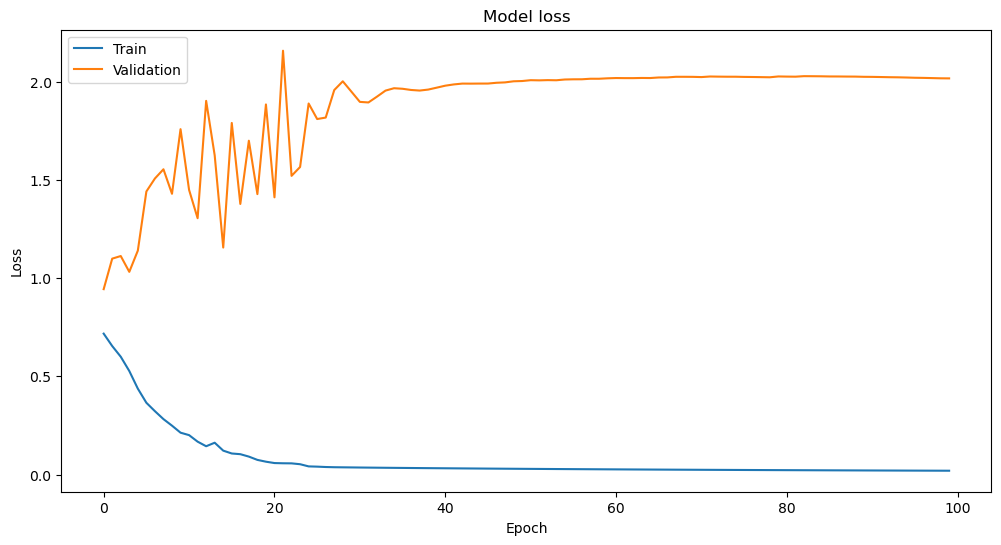

In [17]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [18]:
print(f"Train Accuracy: {accuracy_score(np.argmax(y_train, axis=1), np.argmax(y_train_pred, axis=1)):.4f}") 
print(f"Train Precision: {precision_score(np.argmax(y_train, axis=1), np.argmax(y_train_pred, axis=1), average='binary'):.4f}") 
print(f"Train Recall: {recall_score(np.argmax(y_train, axis=1), np.argmax(y_train_pred, axis=1), average='binary'):.4f}") 
print(f"Train F1-Score: {f1_score(np.argmax(y_train, axis=1), np.argmax(y_train_pred, axis=1), average='binary'):.4f}") 
print(f"Train AUC: {roc_auc_score(np.argmax(y_train, axis=1), np.argmax(y_train_pred, axis=1)):.4f}")
print(f"Train Specificity: {ml_utils.calculate_specificity(np.argmax(y_train, axis=1), np.argmax(y_train_pred, axis=1)):.4f}")

Train Accuracy: 0.6014
Train Precision: 0.5573
Train Recall: 0.9865
Train F1-Score: 0.7122
Train AUC: 0.6014
Train Specificity: 0.2162


In [19]:
print(f"Test Accuracy: {accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1)):.4f}") 
print(f"Test Precision: {precision_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1), average='binary'):.4f}") 
print(f"Test Recall: {recall_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1), average='binary'):.4f}") 
print(f"Test F1-Score: {f1_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1), average='binary'):.4f}") 
print(f"Test AUC: {roc_auc_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1)):.4f}")
print(f"Test Specificity: {ml_utils.calculate_specificity(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1)):.4f}")	

Test Accuracy: 0.8148
Test Precision: 0.7917
Test Recall: 1.0000
Test F1-Score: 0.8837
Test AUC: 0.6875
Test Specificity: 0.3750


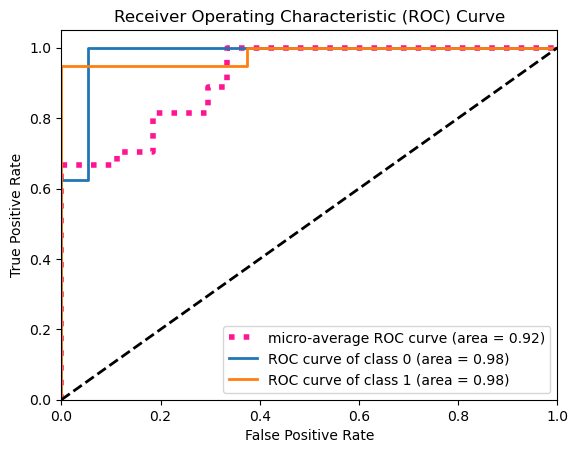

In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve and ROC area for each class
n_classes = y_test.shape[1]
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
# Plot ROC curve
plt.figure()
plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle=':', linewidth=4, label='micro-average ROC curve (area = {0:0.2f})'.format(roc_auc["micro"]))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
